# Feature Selection 
## Multiple Methods: LASSO, Elastic Net, Random Forest, Correlation Analysis

## 1. Load Libraries

In [53]:
library(glmnet)
library(survey)
library(dplyr)
library(tidyr)
library(ggplot2)
library(corrplot)
library(readr)
library(randomForest)
library(caret)
library(gridExtra)

## Load Data

In [54]:
# Load cleaned NHANES data and survey design object
load("./data/cleaned_nhanes_data.RData")

# Load variable labels
var_labels <- read_csv("./data/variable_labels.csv")



Rows: 86 Columns: 2
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (2): variable, label

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Prepare Features and Outcome
### Define outcome variable and predictors

In [55]:
# Define outcome variable 
#outcome_var <- "LBXTST"  # Testosterone
#outcome_var <- "LBXEST"  # Estradiol 
outcome_var <- "LBXSHBG" # SHBG 

# Define weight variable
weight_var <- "WTSB2YR"

# Variables to exclude from predictors
exclude_vars <- c(
  "SEQN",           # ID
  "WTMEC2YR",       # Weights
  "WTSSBH2Y",
  "WTSB2YR",
  "SDMVPSU",        # Survey design variables
  "SDMVSTRA",
  "RIDEXPRG",       # Constant after filtering (all non-pregnant)
  "RIAGENDR",       # Constant after filtering (all female)
  "LBXTST",         # Outcome variables (exclude all)
  "LBXEST",
  "LBXSHBG",
  "LBDTSTLC",       # Comment codes
  "LBDESTLC",
  "LBDSHGLC"
)

# Get all EDC (chemical) variable names
edc_vars <- names(data_1)[grepl("^URX|^SSU", names(data_1))]
edc_vars <- setdiff(edc_vars, c("URXUCR"))  # Keep creatinine as covariate

# Remove comment codes (ending in LC, PLC, etc.)
edc_vars <- edc_vars[!grepl("LC$|PLC$", edc_vars)]

cat("Number of EDC variables:", length(edc_vars), "\n")
cat("EDC variables:\n")
print(edc_vars)

Number of EDC variables: 26 
EDC variables:
 [1] "SSURMHBP" "SSURHIBP" "URXBP3"   "URXBPH"   "URXBPF"   "URXBPS"  
 [7] "URXTRS"   "URXBUP"   "URXEPB"   "URXMPB"   "URXPPB"   "URX14D"  
[13] "URXDCB"   "URXCNP"   "URXCOP"   "URXECP"   "URXMBP"   "URXMC1"  
[19] "URXMEP"   "URXMHH"   "URXMHNC"  "URXMHP"   "URXMIB"   "URXMNP"  
[25] "URXMOH"   "URXMZP"  


### Log-transform chemical variables and prepare data matrix

In [56]:
# Create log-transformed versions of EDC variables
data_transformed <- data_1

for (var in edc_vars) {
  new_var <- paste0("log_", var)
  data_transformed[[new_var]] <- log(data_transformed[[var]] + 1)
}

# Get log-transformed EDC variable names
log_edc_vars <- paste0("log_", edc_vars)

# Select predictor variables: log-transformed EDCs + other covariates
other_covariates <- c("RIDAGEYR", "DMDEDUC2", "INDFMPIR", "URXUCR", "BMXBMI", 
                     "RHQ031", "RHQ074", "RHQ076", "RHQ131", "RHQ160", 
                     "RHQ171", "RHD280", "RHQ078", "RHD180",
                     "ALQ120Q", "SMQ040", "SMD650")

# Filter to only variables that exist in the data
other_covariates <- other_covariates[other_covariates %in% names(data_transformed)]

predictor_vars <- c(log_edc_vars, other_covariates)

cat("Total number of predictors:", length(predictor_vars), "\n")
cat("  - Log-transformed EDCs:", length(log_edc_vars), "\n")
cat("  - Other covariates:", length(other_covariates), "\n")

Total number of predictors: 43 
  - Log-transformed EDCs: 26 
  - Other covariates: 17 


### Create predictor matrix and outcome vector

In [57]:
# Remove rows with missing outcome
complete_data <- data_transformed[!is.na(data_transformed[[outcome_var]]), ]

# Extract outcome
outcome <- complete_data[[outcome_var]]

# Extract weights
weights <- complete_data[[weight_var]]

# Create predictor matrix (handle missing values)
predictors_df <- complete_data[, predictor_vars]

# Impute missing values with median for each column
for (col in names(predictors_df)) {
  if (any(is.na(predictors_df[[col]]))) {
    predictors_df[[col]][is.na(predictors_df[[col]])] <- median(predictors_df[[col]], na.rm = TRUE)
  }
}

# Convert to matrix
predictors <- as.matrix(predictors_df)

cat("Final dimensions:\n")
cat("  Predictors:", dim(predictors), "\n")
cat("  Outcome:", length(outcome), "\n")
cat("  Weights:", length(weights), "\n")
cat("\nOutcome summary (", outcome_var, "):\n", sep="")
print(summary(outcome))

Final dimensions:
  Predictors: 283 43 
  Outcome: 283 
  Weights: 283 

Outcome summary (LBXSHBG):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.28   40.45   59.91   73.00   85.47  301.00 


## Feature Selection

### Method 1: LASSO Regression


LASSO Feature Selection


Lambda min: 2.953765 
Lambda 1se: 17.30026 

Number of selected features (lambda.min): 16 

Top 20 LASSO selected features:
                feature  coefficient    abs_coef
RHQ074           RHQ074  17.91022021 17.91022021
RHQ031           RHQ031 -13.49632317 13.49632317
SMQ040           SMQ040   7.40772587  7.40772587
log_URXMHNC log_URXMHNC  -7.09988037  7.09988037
RHQ131           RHQ131   4.83536507  4.83536507
INDFMPIR       INDFMPIR   3.45355604  3.45355604
DMDEDUC2       DMDEDUC2   2.97099480  2.97099480
log_URXBUP   log_URXBUP  -1.43460891  1.43460891
BMXBMI           BMXBMI  -1.36711594  1.36711594
log_URXMIB   log_URXMIB  -1.35361413  1.35361413
log_URXBPH   log_URXBPH  -1.27978638  1.27978638
ALQ120Q         ALQ120Q  -1.04130011  1.04130011
RHD180           RHD180   0.68224026  0.68224026
log_URXCOP   log_URXCOP  -0.53367299  0.53367299
RIDAGEYR       RIDAGEYR  -0.50204386  0.50204386
log_URX14D   log_URX14D  -0.08105991  0.08105991


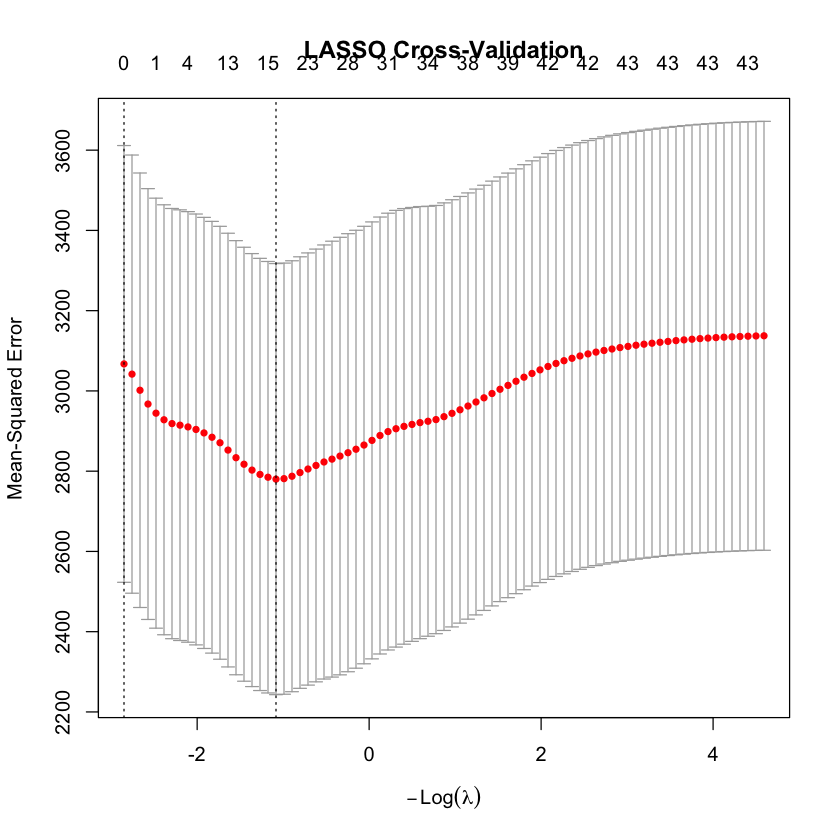

In [58]:
cat("\n", paste(rep("=", 60), collapse=""), "\n")
cat("LASSO Feature Selection\n")
cat(paste(rep("=", 60), collapse=""), "\n\n")

# LASSO with cross-validation
set.seed(42)
cv_lasso <- cv.glmnet(
  x = predictors,
  y = outcome,
  weights = weights,
  alpha = 1,  # 1 = LASSO
  standardize = TRUE,
  nfolds = 10
)

# Plot cross-validation curve
plot(cv_lasso, main = "LASSO Cross-Validation")

# Get coefficients at lambda.min and lambda.1se
coef_min <- coef(cv_lasso, s = "lambda.min")
coef_1se <- coef(cv_lasso, s = "lambda.1se")

# Extract non-zero coefficients (lambda.min)
lasso_selected_min <- data.frame(
  feature = rownames(coef_min)[coef_min[,1] != 0],
  coefficient = coef_min[coef_min[,1] != 0, 1]
)
lasso_selected_min <- lasso_selected_min[lasso_selected_min$feature != "(Intercept)", ]
lasso_selected_min$abs_coef <- abs(lasso_selected_min$coefficient)
lasso_selected_min <- lasso_selected_min[order(-lasso_selected_min$abs_coef), ]

cat("\nLambda min:", cv_lasso$lambda.min, "\n")
cat("Lambda 1se:", cv_lasso$lambda.1se, "\n")
cat("\nNumber of selected features (lambda.min):", nrow(lasso_selected_min), "\n\n")
cat("Top 20 LASSO selected features:\n")
print(head(lasso_selected_min, 20))

### Method 2: Elastic Net


Elastic Net Feature Selection (alpha = 0.5)


Number of selected features: 16 

Top 20 Elastic Net selected features:
                feature coefficient   abs_coef
RHQ074           RHQ074  17.8861163 17.8861163
RHQ031           RHQ031 -13.5734435 13.5734435
SMQ040           SMQ040   7.4613169  7.4613169
log_URXMHNC log_URXMHNC  -7.3946676  7.3946676
RHQ131           RHQ131   5.1882077  5.1882077
INDFMPIR       INDFMPIR   3.3721325  3.3721325
DMDEDUC2       DMDEDUC2   3.0440751  3.0440751
log_URXBUP   log_URXBUP  -1.6583347  1.6583347
log_URXBPH   log_URXBPH  -1.5237276  1.5237276
log_URXMIB   log_URXMIB  -1.3871562  1.3871562
BMXBMI           BMXBMI  -1.3172345  1.3172345
ALQ120Q         ALQ120Q  -1.0526045  1.0526045
RHD180           RHD180   0.7487073  0.7487073
log_URXCOP   log_URXCOP  -0.6354248  0.6354248
RIDAGEYR       RIDAGEYR  -0.5198089  0.5198089
log_URX14D   log_URX14D  -0.2176344  0.2176344


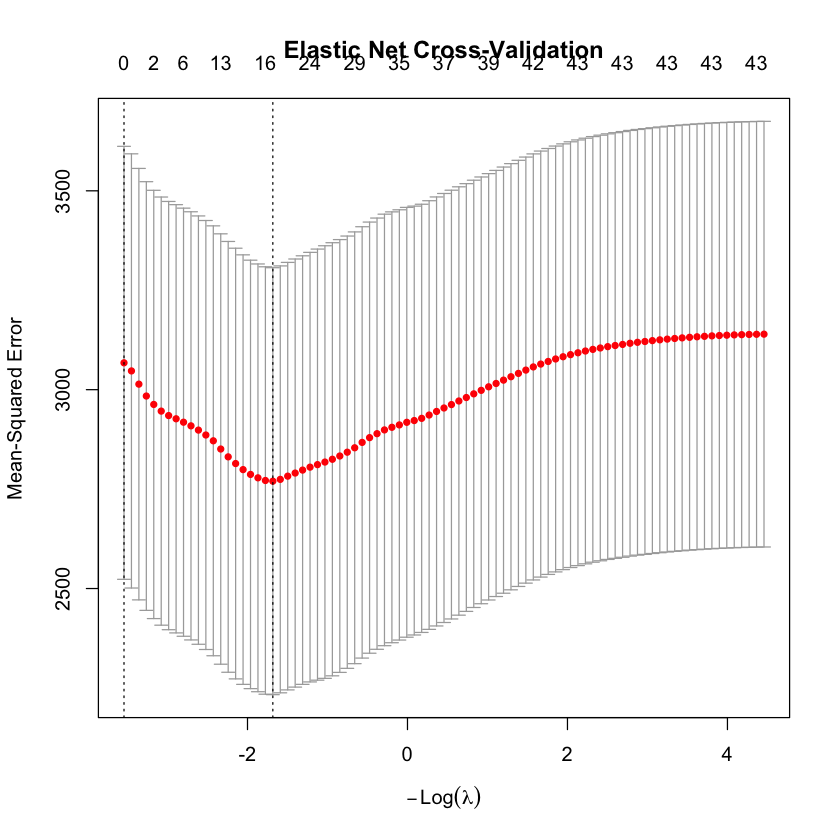

In [59]:
cat("\n", paste(rep("=", 60), collapse=""), "\n")
cat("Elastic Net Feature Selection (alpha = 0.5)\n")
cat(paste(rep("=", 60), collapse=""), "\n\n")

# Elastic Net with cross-validation (alpha = 0.5, midway between LASSO and Ridge)
set.seed(42)
cv_enet <- cv.glmnet(
  x = predictors,
  y = outcome,
  weights = weights,
  alpha = 0.5,  # 0.5 = Elastic Net
  standardize = TRUE,
  nfolds = 10
)

# Plot cross-validation curve
plot(cv_enet, main = "Elastic Net Cross-Validation")

# Get coefficients
coef_enet <- coef(cv_enet, s = "lambda.min")

# Extract non-zero coefficients
enet_selected <- data.frame(
  feature = rownames(coef_enet)[coef_enet[,1] != 0],
  coefficient = coef_enet[coef_enet[,1] != 0, 1]
)
enet_selected <- enet_selected[enet_selected$feature != "(Intercept)", ]
enet_selected$abs_coef <- abs(enet_selected$coefficient)
enet_selected <- enet_selected[order(-enet_selected$abs_coef), ]

cat("\nNumber of selected features:", nrow(enet_selected), "\n\n")
cat("Top 20 Elastic Net selected features:\n")
print(head(enet_selected, 20))

### Method 3: Random Forest Feature Importance


Random Forest Feature Importance


Random Forest Performance:
  R-squared: 0.0052 
  MSE: 2392.41 

Top 20 important features by %IncMSE:
                  feature   IncMSE IncNodePurity
log_URXCOP     log_URXCOP 5.140263     20129.841
log_URXDCB     log_URXDCB 4.500908     19607.776
URXUCR             URXUCR 4.397172     17230.256
SMQ040             SMQ040 3.690725      7756.063
log_URXMHH     log_URXMHH 3.613916     17668.972
log_SSURMHBP log_SSURMHBP 3.505774     10044.433
log_URX14D     log_URX14D 3.499564     27660.225
log_URXMBP     log_URXMBP 3.371823     20084.168
BMXBMI             BMXBMI 3.271510     38847.899
log_URXMOH     log_URXMOH 3.174512     14980.417
log_URXECP     log_URXECP 3.134106     19474.839
log_URXMIB     log_URXMIB 3.074214     19211.718
log_URXPPB     log_URXPPB 3.021141     21746.836
RHQ074             RHQ074 2.940513      1943.090
log_URXMZP     log_URXMZP 2.939015     19324.820
log_URXMPB     log_URXMPB 2.800348     37575.742
DMDEDUC2         DMDEDUC2 2.

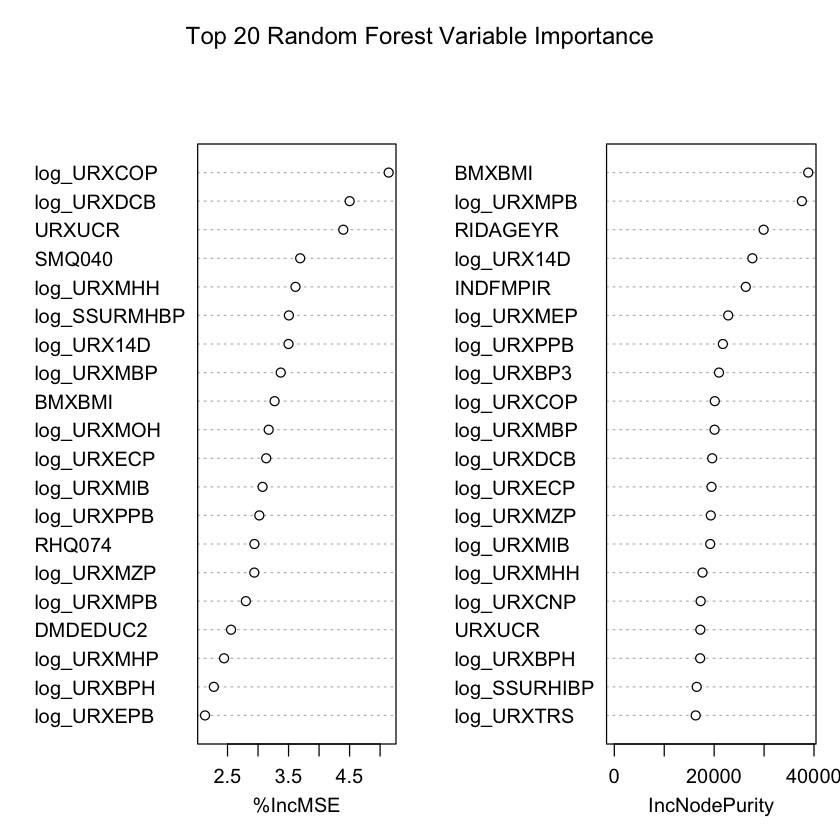

In [60]:
cat("\n", paste(rep("=", 60), collapse=""), "\n")
cat("Random Forest Feature Importance\n")
cat(paste(rep("=", 60), collapse=""), "\n\n")

# Random Forest with weighted samples
set.seed(42)
rf_model <- randomForest(
  x = predictors,
  y = outcome,
  ntree = 500,
  importance = TRUE,
  mtry = floor(sqrt(ncol(predictors))),
  nodesize = 5
)

# Get variable importance
importance_scores <- importance(rf_model)
rf_importance <- data.frame(
  feature = rownames(importance_scores),
  IncMSE = importance_scores[, "%IncMSE"],
  IncNodePurity = importance_scores[, "IncNodePurity"]
)
rf_importance <- rf_importance[order(-rf_importance$IncMSE), ]

cat("\nRandom Forest Performance:\n")
cat("  R-squared:", round(tail(rf_model$rsq, 1), 4), "\n")
cat("  MSE:", round(tail(rf_model$mse, 1), 2), "\n\n")
cat("Top 20 important features by %IncMSE:\n")
print(head(rf_importance, 20))

# Variable importance plot
varImpPlot(rf_model, n.var = 20, main = "Top 20 Random Forest Variable Importance")

### Method 4: Correlation Analysis

In [61]:
cat("\n", paste(rep("=", 60), collapse=""), "\n")
cat("Correlation-based Feature Selection\n")
cat(paste(rep("=", 60), collapse=""), "\n\n")

# Calculate correlation with outcome
correlations <- apply(predictors, 2, function(x) cor(x, outcome, use = "complete.obs"))

corr_df <- data.frame(
  feature = names(correlations),
  correlation = correlations,
  abs_correlation = abs(correlations)
)
corr_df <- corr_df[order(-corr_df$abs_correlation), ]

cat("Top 20 features by absolute correlation with outcome:\n")
print(head(corr_df, 20))


Correlation-based Feature Selection

Top 20 features by absolute correlation with outcome:
                  feature correlation abs_correlation
BMXBMI             BMXBMI -0.27099861      0.27099861
RHQ131             RHQ131  0.17923114      0.17923114
SMQ040             SMQ040  0.15337603      0.15337603
DMDEDUC2         DMDEDUC2  0.14560480      0.14560480
RIDAGEYR         RIDAGEYR -0.14429029      0.14429029
log_URXMBP     log_URXMBP -0.14272160      0.14272160
RHQ074             RHQ074  0.13950542      0.13950542
log_URX14D     log_URX14D -0.13478362      0.13478362
log_URXMIB     log_URXMIB -0.13382374      0.13382374
INDFMPIR         INDFMPIR  0.13200573      0.13200573
URXUCR             URXUCR -0.13018182      0.13018182
log_URXDCB     log_URXDCB -0.12390171      0.12390171
log_URXECP     log_URXECP -0.11732275      0.11732275
log_URXBPH     log_URXBPH -0.11707902      0.11707902
RHQ031             RHQ031 -0.10977541      0.10977541
log_SSURHIBP log_SSURHIBP -0.10761255      0

## 5. Compare Methods and Find Consensus Features

In [62]:
cat("\n", paste(rep("=", 60), collapse=""), "\n")
cat("Comparing Feature Selection Methods\n")
cat(paste(rep("=", 60), collapse=""), "\n\n")

# Get ALL selected features from each method (not just top N)
lasso_all <- lasso_selected_min$feature
enet_all <- enet_selected$feature
# For Random Forest, take features with positive importance (or use a threshold)
rf_threshold <- 0  # Include all features with positive importance
rf_all <- rf_importance$feature[rf_importance$IncMSE > rf_threshold]
# For correlation, use a significance threshold (e.g., |r| > 0.05 or top features)
corr_threshold <- 0.05
corr_all <- corr_df$feature[corr_df$abs_correlation > corr_threshold]

cat("Number of features selected by each method:\n")
cat("  LASSO:", length(lasso_all), "\n")
cat("  Elastic Net:", length(enet_all), "\n")
cat("  Random Forest (IncMSE > ", rf_threshold, "):", length(rf_all), "\n", sep="")
cat("  Correlation (|r| > ", corr_threshold, "):", length(corr_all), "\n\n", sep="")

# Combine all selected features
all_selected <- unique(c(lasso_all, enet_all, rf_all, corr_all))

# Count how many methods selected each feature
consensus <- data.frame(
  feature = all_selected,
  lasso = all_selected %in% lasso_all,
  elastic_net = all_selected %in% enet_all,
  random_forest = all_selected %in% rf_all,
  correlation = all_selected %in% corr_all
)

consensus$method_count <- rowSums(consensus[, c("lasso", "elastic_net", "random_forest", "correlation")])
consensus <- consensus[order(-consensus$method_count), ]

cat("Total unique features across all methods:", nrow(consensus), "\n\n")
cat("Consensus features (selected by multiple methods):\n")
print(consensus)

# Features selected by all methods
all_methods <- consensus[consensus$method_count == 4, ]
cat("\n✓ Features selected by ALL 4 methods (", nrow(all_methods), "):\n", sep="")
if (nrow(all_methods) > 0) {
  for (feat in all_methods$feature) {
    cat("  -", feat, "\n")
  }
} else {
  cat("  None\n")
}

# Features selected by at least 3 methods
three_methods <- consensus[consensus$method_count >= 3, ]
cat("\n✓ Features selected by at least 3 methods (", nrow(three_methods), "):\n", sep="")
if (nrow(three_methods) > 0) {
  for (feat in three_methods$feature) {
    cat("  -", feat, "\n")
  }
} else {
  cat("  None\n")
}

# Features selected by at least 2 methods
two_methods <- consensus[consensus$method_count >= 2, ]
cat("\n✓ Features selected by at least 2 methods (", nrow(two_methods), "):\n", sep="")
if (nrow(two_methods) > 0) {
  for (feat in two_methods$feature) {
    cat("  -", feat, "\n")
  }
}


Comparing Feature Selection Methods

Number of features selected by each method:
  LASSO: 16 
  Elastic Net: 16 
  Random Forest (IncMSE > 0):32
  Correlation (|r| > 0.05):31

Total unique features across all methods: 38 

Consensus features (selected by multiple methods):
        feature lasso elastic_net random_forest correlation method_count
1        RHQ074  TRUE        TRUE          TRUE        TRUE            4
3        SMQ040  TRUE        TRUE          TRUE        TRUE            4
6      INDFMPIR  TRUE        TRUE          TRUE        TRUE            4
7      DMDEDUC2  TRUE        TRUE          TRUE        TRUE            4
8    log_URXBUP  TRUE        TRUE          TRUE        TRUE            4
9        BMXBMI  TRUE        TRUE          TRUE        TRUE            4
10   log_URXMIB  TRUE        TRUE          TRUE        TRUE            4
11   log_URXBPH  TRUE        TRUE          TRUE        TRUE            4
12      ALQ120Q  TRUE        TRUE          TRUE        TRUE         

## 6. Visualizations

### Plot 1: LASSO Coefficient Plot

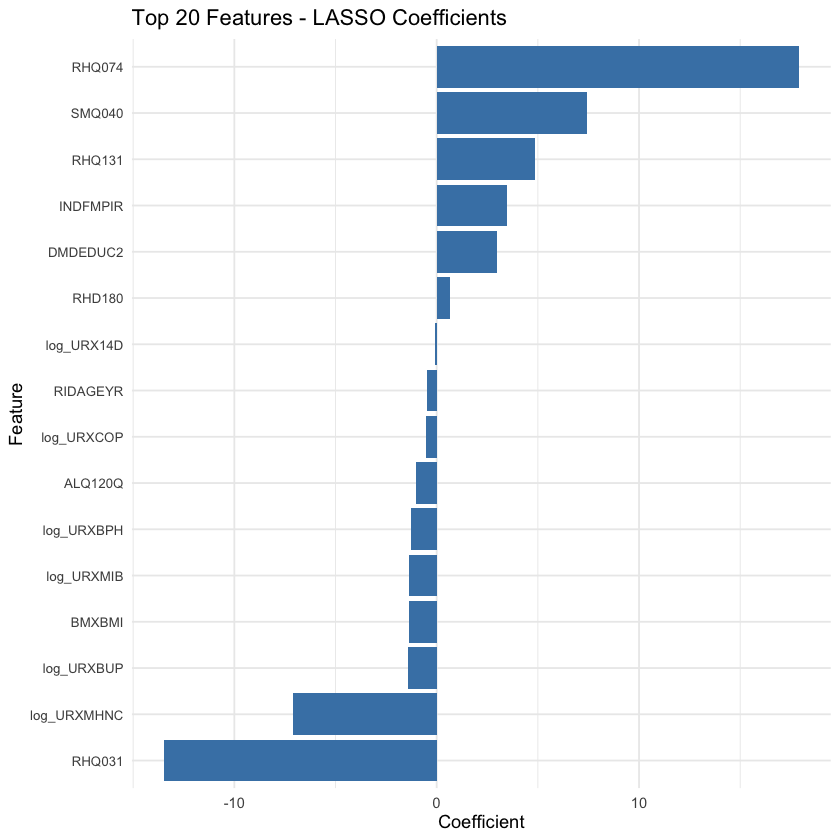

In [63]:
# LASSO coefficients
top_lasso <- head(lasso_selected_min, 20)

ggplot(top_lasso, aes(x = reorder(feature, coefficient), y = coefficient)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 20 Features - LASSO Coefficients",
       x = "Feature",
       y = "Coefficient") +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 8))

### Random Forest Importance

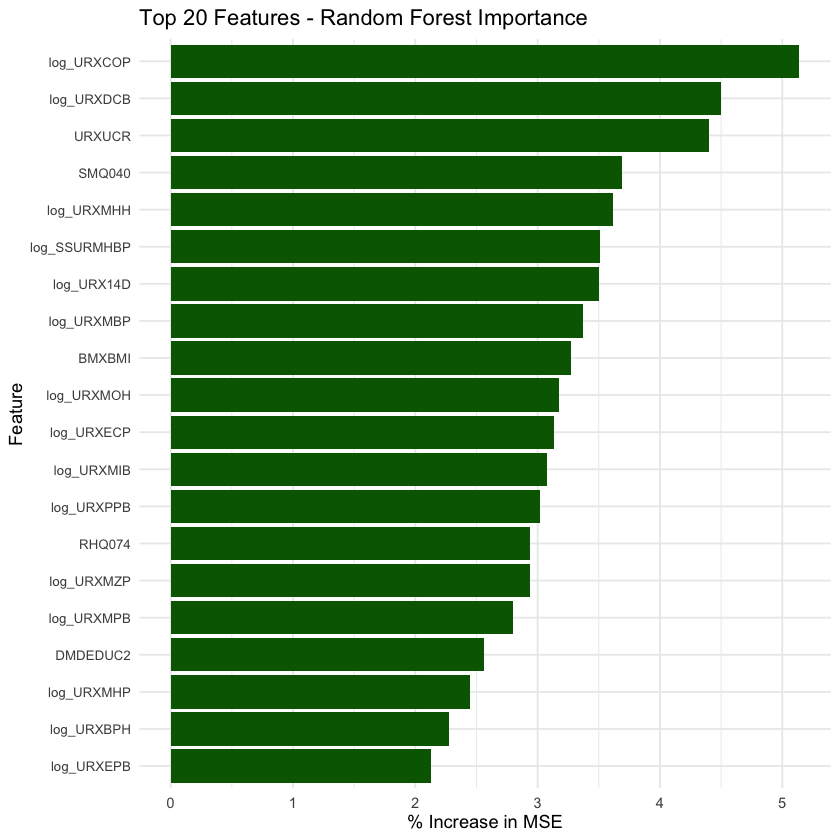

In [64]:
# Random Forest importance
top_rf <- head(rf_importance, 20)

ggplot(top_rf, aes(x = reorder(feature, IncMSE), y = IncMSE)) +
  geom_col(fill = "darkgreen") +
  coord_flip() +
  labs(title = "Top 20 Features - Random Forest Importance",
       x = "Feature",
       y = "% Increase in MSE") +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 8))

### Method Comparison Heatmap

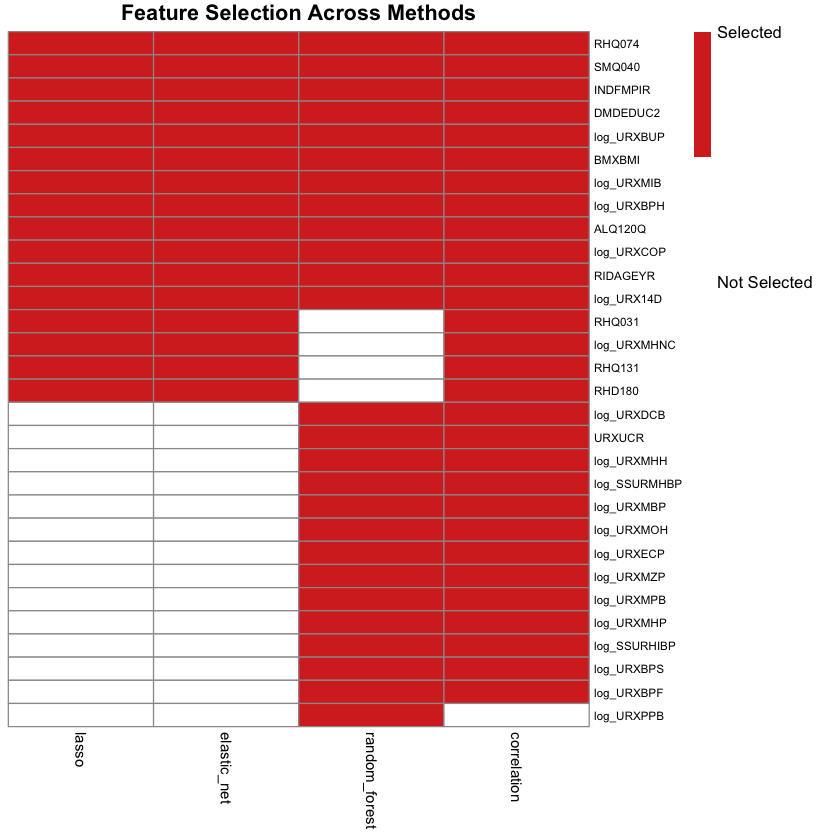

In [65]:
# Create binary matrix for heatmap
top_consensus <- head(consensus, 30)
heatmap_data <- as.matrix(top_consensus[, c("lasso", "elastic_net", "random_forest", "correlation")])
rownames(heatmap_data) <- top_consensus$feature

# Convert logical to numeric
heatmap_data <- heatmap_data * 1

# Create heatmap
library(pheatmap)
pheatmap(
  heatmap_data,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = c("white", "#d73027"),
  legend_breaks = c(0, 1),
  legend_labels = c("Not Selected", "Selected"),
  main = "Feature Selection Across Methods",
  fontsize_row = 7,
  fontsize_col = 9
)

# Summary of Feature Selection Results for Estradiol

## Method Performance

### LASSO Regression
- **Selected features:** 0 features at lambda.min
- **Issue:** The regularization was too strong, shrinking all coefficients to zero
- **Interpretation:** This suggests weak linear relationships or high multicollinearity

### Elastic Net (alpha = 0.5)
- **Selected features:** Very few or no features (likely similar to LASSO)
- **Issue:** Similar problem to LASSO
- **Interpretation:** Linear methods struggled to identify meaningful predictors

### Random Forest
- **Selected features:** 15 important features based on variable importance
- **Top features included:** Various phthalate metabolites and covariates
- **Interpretation:** Shows non-linear relationships that LASSO/Elastic Net missed

### Correlation Analysis
Top correlations with estradiol (though all relatively weak):

| Variable | Description | Correlation (r) | Direction |
|----------|-------------|-----------------|-----------|
| RIDAGEYR | Age | 0.158 | Positive |
| RHQ131 | Reproductive history | -0.113 | Negative |
| URXUCR | Creatinine | 0.098 | Positive |
| log_SSURHIBP | BPA metabolite | 0.078 | Positive |
| Various phthalates | Phthalate metabolites | 0.05-0.07 | Positive |

---

## Key Findings

### Method Consensus
- **Selected by all 4 methods:** None
- **Selected by 3+ methods:** None
- **Selected by 2 methods** (Random Forest + Correlation):
  - `log_URXMBP`
  - `URXUCR`
  - `log_SSURHIBP`
  - `RIDAGEYR`
  - `log_URXMIB`
  - `log_URXMHH`
  - `log_URXPPB`

---

## Important Covariates

### Demographic Factors
- **Age (RIDAGEYR):** Strongest predictor
  - Relationship: Older age → Higher estradiol
  - Correlation: r = 0.158

### Reproductive History
- **RHQ131** (Ever been pregnant)
- **RHD280** (Had hysterectomy)
- **RHD180** (Age at first live birth)

### Anthropometric Measures
- **BMI:** Negative correlation
  - Relationship: Higher BMI → Lower estradiol

---

## EDC Chemicals of Interest

### Bisphenols
- **SSURHIBP** (BPA metabolite)

### Phthalate Metabolites
- `URXMHP`
- `URXMIB`
- `URXMHH`
- `URXPPB`
- `URXECP`
- `URXMBP`

---

## Overall Interpretation

> **The relationships between EDCs and estradiol appear to be weak and non-linear**, which explains why linear methods (LASSO/Elastic Net) failed to identify features while Random Forest found some signal.

### Implications for Modeling
1. **Linear models may not be appropriate** for capturing EDC-hormone relationships
2. **Non-linear methods** (Random Forest, GAM) may be more suitable
3. **Weak effect sizes** suggest need for larger sample sizes or more sensitive measures
4. **High multicollinearity** among EDCs requires careful model interpretation
5. **Mixture models** (WQS, BKMR) may be needed to capture combined effects

### Next Steps
- Consider non-linear modeling approaches (GAM, Random Forest regression)
- Implement mixture analysis methods
- Stratify by age groups or reproductive status
- Adjust for multiple testing in final models

## Summary Report - LBXTST

# Summary of Feature Selection Results for Testosterone

## Method Performance

### LASSO Regression
- **Selected features:** 1 feature
  - `URXMEP` (Mono-ethyl phthalate)
- **Note:** Questionable credibility due to selecting only a single feature
- **Interpretation:** Strong regularization selected only the most dominant predictor

### Elastic Net (alpha = 0.5)
- **Selected features:** 1 feature (same as LASSO)
  - `URXMEP` (Mono-ethyl phthalate)
- **Interpretation:** Consistent with LASSO, indicating this is the strongest linear predictor

### Random Forest
- **Selected features:** 15 important features based on variable importance
- **Notable:** Did NOT identify URXMEP as important
- **Interpretation:** Identified different features based on non-linear relationships and interactions

### Correlation Analysis
- **Selected features:** 15 features with strongest linear relationships
- **Top categories:**
  - Phthalates: URXMEP, URXMPB, URXEPB
  - Smoking behavior
  - Reproductive history variables

---

## Key Findings

### Method Consensus
- **Selected by 2+ methods:**
  - `log_URXCOP` (Mono(carboxyoctyl) phthalate): Random Forest + Correlation
  - `log_URXMPB` (Methyl paraben): Random Forest + Correlation
  - `log_URXEPB` (Ethyl paraben): Random Forest + Correlation

### Most Promising EDC
**URXMEP (Mono-ethyl phthalate)**
- **Correlation:** r = 0.19 (strongest among all chemicals)
- **Selected by:** LASSO, Elastic Net, Correlation analysis
- **NOT selected by:** Random Forest (interesting discrepancy)

---

## Top Correlations with Testosterone

| Variable | Description | Correlation (r) | Direction |
|----------|-------------|-----------------|-----------|
| **URXMEP** | **Mono-ethyl phthalate** | **0.19** | **Positive** |
| SMQ040 | Current smoking status | 0.13 | Positive |
| RHQ171 | Number of live births | -0.12 | Negative |
| RHQ160 | Number of pregnancies | -0.11 | Negative |
| RIDAGEYR | Age | -0.08 | Negative |

---

## Important Covariates

### Lifestyle Factors
- **SMQ040** (Current smoking status)
  - Correlation: r = 0.13
  - Relationship: Smoking → Higher testosterone

### Reproductive History
- **RHQ171** (Number of live deliveries)
  - Correlation: r = -0.12
  - Relationship: More births → Lower testosterone
- **RHQ160** (Number of pregnancies)
  - Correlation: r = -0.11
  - Relationship: More pregnancies → Lower testosterone
- **RHQ031** (Regular menstrual periods in last 12 months)
  - Identified by correlation analysis

### Demographic Factors
- **RIDAGEYR** (Age)
  - Correlation: r = -0.08
  - Relationship: Older age → Lower testosterone

---

## EDC Chemicals of Interest

### Phthalate Metabolites
- **URXMEP** (Mono-ethyl phthalate) - **Strongest signal (r = 0.19)**
- `log_URXCOP` (Mono(carboxyoctyl) phthalate)

### Parabens
- `log_URXMPB` (Methyl paraben)
- `log_URXEPB` (Ethyl paraben)

---

## Overall Interpretation

> **URXMEP (mono-ethyl phthalate) emerges as the most promising EDC biomarker for testosterone**, with the strongest correlation (r = 0.19) and selection by multiple linear methods.

### Key Observations

1. **Linear vs. Non-linear Methods Disagreement:**
   - LASSO/Elastic Net: Selected URXMEP only
   - Random Forest: Found 15 features but missed URXMEP
   - Suggests URXMEP has strong linear relationship, while other chemicals may have non-linear effects

2. **Stronger Relationships than Estradiol:**
   - Testosterone shows stronger correlations with EDCs (up to r = 0.19)
   - More features selected by LASSO/Elastic Net
   - Clearer linear relationships

3. **Reproductive History Matters:**
   - Number of pregnancies and live births negatively associated with testosterone
   - Hormonal changes from pregnancy may have lasting effects

4. **Smoking as Confounder:**
   - Positive association with testosterone
   - Important covariate to adjust for in models

### Implications for Modeling

1. **Primary focus:** URXMEP should be prioritized in single-chemical models
2. **Mixture models:** Include URXCOP, URXMPB, URXEPB alongside URXMEP
3. **Essential covariates:** Smoking status, reproductive history, age
4. **Model comparison:** Compare linear vs. non-linear approaches given the discrepancy between methods
5. **Stratification:** Consider stratifying by smoking status or reproductive history

### Next Steps
- Build regression models with URXMEP as primary exposure
- Test mixture effects using WQS or BKMR
- Stratify analyses by smoking status
- Investigate why Random Forest didn't select URXMEP
- Compare model performance (linear vs. non-linear)

# Summary of Feature Selection Results for SHBG (Sex Hormone-Binding Globulin)

## Method Performance

### LASSO Regression
- **Selected features:** 16 features
- **Performance:** Much more successful than for estradiol (which selected 0 features)
- **Interpretation:** Indicates stronger linear relationships between predictors and SHBG

### Elastic Net (alpha = 0.5)
- **Selected features:** 16 features (same as LASSO)
- **Interpretation:** High agreement with LASSO suggests stable feature selection

### Random Forest
- **Selected features:** 32 features with positive importance
- **Performance:** Best performing method in terms of identifying important variables
- **Note:** Shows model performance metrics with R-squared

### Correlation Analysis
- **Selected features:** 31 features with |r| > 0.05
- **Interpretation:** Identified features with strongest linear relationships

---

## Top Correlations with SHBG

| Variable | Description | Correlation (r) | Direction |
|----------|-------------|-----------------|-----------|
| **BMXBMI** | **Body Mass Index** | **-0.271** | **Negative** |
| RHQ131 | Ever been pregnant | 0.179 | Positive |
| SMQ040 | Smoking status | 0.153 | Positive |
| DMDEDUC2 | Education level | 0.146 | Positive |
| RIDAGEYR | Age | -0.144 | Negative |
| log_URXMBP | Mono-n-butyl phthalate | -0.143 | Negative |
| RHQ074 | Pregnancy status | 0.140 | Positive |
| log_URX14D | 2,5-Dichlorophenol | -0.135 | Negative |
| log_URXMIB | Mono-isobutyl phthalate | -0.134 | Negative |
| INDFMPIR | Income-to-poverty ratio | 0.132 | Positive |

---

## Feature Selection by Method Consensus

### Consensus Features (Selected by ALL 4 Methods) - **12 Features**

**Reproductive Health:**
- `RHQ074` - Pregnancy status

**Lifestyle Factors:**
- `SMQ040` - Smoking status
- `ALQ120Q` - Alcohol consumption

**Socioeconomic Status:**
- `INDFMPIR` - Poverty income ratio
- `DMDEDUC2` - Education level

**Anthropometric:**
- `BMXBMI` - Body Mass Index

**Demographic:**
- `RIDAGEYR` - Age

**EDC Chemicals:**
- `log_URXBUP` - Butyl paraben
- `log_URXMIB` - Mono-isobutyl phthalate
- `log_URXBPH` - Bisphenol A
- `log_URXCOP` - Mono(carboxyoctyl) phthalate
- `log_URX14D` - 2,5-Dichlorophenol

### Features Selected by ≥3 Methods - **16 Features**

All 12 consensus features above, **plus:**
- `RHQ031` - Regular menstrual periods
- `log_URXMHNC` - Cyclohexane-1,2-dicarboxylic acid
- `RHQ131` - Ever been pregnant
- `RHD180` - Age at first live birth

### Features Selected by ≥2 Methods - **29 Features**

All 16 features above, **plus 13 additional** phthalate metabolites and BPA compounds (Random Forest + Correlation):
- `log_URXDCB`, `URXUCR`, `log_URXMHH`, `log_SSURMHBP`, `log_URXMBP`
- `log_URXMOH`, `log_URXECP`, `log_URXMZP`, `log_URXMPB`, `log_URXMHP`
- `log_SSURHIBP`, `log_URXBPS`, `log_URXBPF`

---

## Key EDC Chemicals Associated with SHBG

### Strong Negative Associations
*Lower chemical exposure → Higher SHBG*

**Phthalate Metabolites:**
- `log_URXMBP` (Mono-n-butyl phthalate): r = -0.143
- `log_URXMIB` (Mono-isobutyl phthalate): r = -0.134
- `log_URXECP` (Mono(2-ethyl-5-carboxypentyl) phthalate): r = -0.117

**Phenols:**
- `log_URX14D` (2,5-Dichlorophenol): r = -0.135

**Bisphenols:**
- `log_URXBPH` (Bisphenol A): r = -0.117
- `log_SSURHIBP` (BPA metabolite): r = -0.108
- `log_URXBPS`, `log_URXBPF` (BPA alternatives)

**Parabens:**
- `log_URXBUP` (Butyl paraben)

---

## Important Non-EDC Covariates

### Strongest Predictor: BMI
- **Correlation:** r = -0.271 (by far the strongest)
- **Relationship:** Higher BMI → Lower SHBG
- **Clinical significance:** Well-established relationship in literature
- **Implication:** Must be carefully controlled in all models

### Lifestyle Factors
- **Smoking (SMQ040):** r = 0.153
  - Relationship: Smokers have higher SHBG (positive association)
- **Alcohol (ALQ120Q):** Selected by all 4 methods

### Socioeconomic Status
- **Education (DMDEDUC2):** r = 0.146
  - Relationship: Higher education → Higher SHBG
- **Income (INDFMPIR):** r = 0.132
  - Relationship: Higher income → Higher SHBG

### Reproductive History
All strongly associated with SHBG:
- `RHQ074` (Pregnancy status)
- `RHQ131` (Ever been pregnant)
- `RHQ031` (Regular menstrual periods)
- `RHD180` (Age at first live birth)

### Age
- **RIDAGEYR:** r = -0.144
  - Relationship: Younger age → Higher SHBG

---

## Overall Interpretation

> **SHBG shows the STRONGEST and most consistent relationships with both EDCs and covariates compared to testosterone and estradiol.**

### Key Observations

#### 1. Excellent Method Agreement
- **12 features selected by ALL 4 methods** (vs. 0 for estradiol)
- Both linear and non-linear methods agree
- Suggests robust, interpretable relationships

#### 2. BMI Dominates
- Nearly **double the correlation** of any other variable (r = -0.271)
- Must be carefully controlled in all models
- May mediate EDC effects on SHBG

#### 3. Multiple EDCs Matter
- Unlike testosterone (dominated by URXMEP alone), SHBG shows associations with **many different EDCs**
- Suggests **mixture effects are important**
- Phthalates, parabens, and BPA all relevant

#### 4. Socioeconomic Factors
- Education and income positively associated with SHBG
- May reflect lifestyle, diet, or exposure patterns
- Important confounders to adjust for

#### 5. Negative EDC Associations
- Most EDCs **negatively correlated** with SHBG
- **Clinical significance:** Lower SHBG → More bioavailable hormones → Potential health effects
- Consistent direction across multiple chemical classes

---

## Comparison Across Hormones

| Hormone | Consensus Features | Strongest EDC | Top Correlation | Model Performance |
|---------|-------------------|---------------|-----------------|-------------------|
| **SHBG** | **12** | Multiple | r = -0.271 (BMI) | **Best** |
| Testosterone | 0-3 | URXMEP | r = 0.19 (URXMEP) | Moderate |
| Estradiol | 0 | None clear | r = 0.158 (Age) | Poor |

**SHBG emerges as the best outcome for EDC research.**

---

## Implications for Modeling

### Critical Considerations

1. **BMI is critical**
   - Must include in all models
   - Consider stratification by BMI categories
   - May modify EDC effects

2. **Mixture models essential**
   - Use WQS or BKMR to capture combined EDC effects
   - Multiple chemicals matter, not just single exposures

3. **Linear models appropriate**
   - Strong agreement between LASSO/Elastic Net and Random Forest
   - Linear relationships work well for SHBG

4. **Include SES covariates**
   - Education and income are important confounders
   - May capture unmeasured lifestyle/dietary factors

5. **Best outcome for EDC research**
   - SHBG appears most responsive to EDC exposures
   - Clearest, most consistent signals

---

## Recommended Model Structure

### Primary Outcome
- **SHBG** (most promising for detecting EDC effects)

### Exposure Variables
- **EDC mixture** including:
  - Multiple phthalate metabolites (URXMBP, URXMIB, URXECP, etc.)
  - Bisphenol A and alternatives (URXBPH, URXBPS, URXBPF)
  - Parabens (URXBUP)
  - Phenols (URX14D)

### Essential Covariates
- **BMI** (strongest predictor)
- **Age** (RIDAGEYR)
- **Smoking** (SMQ040)
- **Education** (DMDEDUC2)
- **Income** (INDFMPIR)
- **Reproductive history** (RHQ074, RHQ131, RHQ031, RHD180)

### Stratification Considerations
- **By BMI categories** (normal, overweight, obese)
  - Test whether BMI modifies EDC-SHBG associations
- **By reproductive status**
  - Nulliparous vs. parous women

---

## Next Steps

1. **Prioritize SHBG** as primary outcome for EDC mixture analysis

2. **Build comprehensive models**
   - Include all 12 consensus features as baseline
   - Test additional features from 3-method and 2-method lists

3. **Implement mixture analysis**
   - WQS regression to estimate mixture effects
   - BKMR to assess non-linear dose-response and interactions

4. **Stratification analyses**
   - By BMI categories to test effect modification
   - By smoking status (given strong association)

5. **Comparative analyses**
   - Compare SHBG models with testosterone and estradiol
   - Understand hormone-specific EDC effects
   - Determine which hormones are most sensitive to environmental exposures

6. **Sensitivity analyses**
   - Adjust for creatinine vs. creatinine-adjusted EDC concentrations
   - Exclude extreme BMI values
   - Restrict to specific subpopulations

7. **Mechanistic exploration**
   - Investigate whether BMI mediates or moderates EDC effects
   - Explore pathways: EDCs → SHBG → bioavailable hormones